In [120]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [ ]:
DT = 1
Q0 = 17921.57581 

In [144]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
display(data)

,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415552,15.9,1.4,2404.0,2.588773,6.969502,0.494206,-2.285347,3.283184,-0.694411,247,-0.020117,-0.000300,0.064722
415553,15.9,1.4,2405.0,2.568657,6.969502,0.493907,-2.285347,3.281990,-0.713334,247,-0.020923,-0.000300,0.064333
415554,15.9,1.4,2406.0,2.547734,6.969502,0.493607,-2.285347,3.280796,-0.733063,247,-0.021729,-0.000300,0.063944
415555,15.9,1.4,2407.0,2.526005,6.969502,0.493307,-2.285347,3.279602,-0.753597,247,-0.021729,-0.000300,0.063556


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [208]:
# Batch data
feature_cols = ['I', 'u', 'Ue', 'soc']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([248, 7049, 4])  (padded, use mask for loss)
mask      : torch.Size([248, 7049])


In [251]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//2, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//2, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


In [240]:
def ECM_box(R, I, U_eq):
    """ V_t = U_eq(SoC) - R_NN(SoC) * I """
    return U_eq - R * I

first_rx = data.groupby('u')['F'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
print(k.values[0])

def Mech_box(Fs, u, k=k.values[0]):
    """ F = Fs_NN(SoC) - k * delta_u """
    return Fs - k * u

def step(Fs, dFs, dt):
    return Fs + dt * dFs

0.5316441632537718


In [ ]:
import torch.nn.functional as TF

class NeuralODE(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.fs_dot_net = nn.Sequential(     
            nn.Linear(5, hidden_size),   # [Fs_t, I_t, u_t, U_eq_t, soc]
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)   # output: dFs/dt
        )
        self.r0_net = nn.Sequential(
            nn.Linear(4, hidden_size),  # [I_t, u_t, U_eq_t, soc_t]
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def r_forward(self, x_b):
        R0_raw = self.r0_net(x_b)
        R0 = TF.softplus(R0_raw).squeeze(-1)  # Ensure positivity and (B, T)
        return R0

    def rc_rollout(self, x_b, V_rc0):
        '''
        x_b : (B, T, 4)  (I, u, U_eq, soc)
        V_rc0 : (B,)       initial RC voltage for each trajectory
        '''
        V_rc = V_rc0
        V_rc_preds = []
        T = x_b.shape[1]

        # Rollout
        for t in range(T):
            print(f'{t}/{T}', end='\r')
            ode_input = torch.cat([V_rc.unsqueeze(-1), x_b[:, t, :]], dim=-1)  # (B, Cx+1)
            dV_rc = self.fs_dot_net(ode_input).squeeze(-1)     # (B,)
            
            V_rc = step(V_rc, dV_rc, dt=DT)
            V_rc_preds.append(V_rc)
            
        return torch.stack(V_rc_preds, dim=1)
    
    def f_rollout(self, x_b, Fs0):
        '''
        x_b : (B, T, 4)  (I, u, U_eq, soc)
        Fs0 : (B,)       initial swelling force for each trajectory
        '''
        Fs_preds = []
        T = x_b.shape[1]

        # Rollout
        for t in range(T):
            # print(f'{t}/{T}', end='\r')
            ode_input = torch.cat([Fs0.unsqueeze(-1), x_b[:, t, :]], dim=-1)  # (B, Cx+1)
            dF = self.fs_dot_net(ode_input).squeeze(-1)     # (B,)
            
            Fs0 = step(Fs0, dF, dt=DT)
            Fs_preds.append(Fs0)
            
        return torch.stack(Fs_preds, dim=1)
    
    
    def forward(self, x_b, V_rc0, Fs0, dt=2.0):
        I = x_b[:, :, 0]    # (B, T)
        u = x_b[:, :, 1]    # (B, T)
        U_eq = x_b[:, :, 2] # (B, T)


        R0 = self.r_forward(x_b)
        V_rc = self.rc_rollout(x_b, V_rc0)
        # Fs = self.f_rollout(x_b, F0)

        eta_pred = R0 * I + V_rc     # (B, T) Overpotential
        V_pred   = U_eq - eta_pred   # (B, T)
        # F_pred = Mech_box(Fs, u)

        return V_pred, eta_pred#, F_pred

model = NeuralODE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def masked_mse(y_pred, y_target, mask):
    '''
    y_pred, y_true : (B, T_max)
    mask           : (B, T_max)      True where valid
    '''
    sq_err = (y_pred - y_target) ** 2
    return sq_err[mask].mean()   

def training(epochs=30):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

    model.train()
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0
        tot_time = 0.

        for x_b, y_b, mask_b in loader_train:   # Start: one trajectory (B=1, T, C) at a time

            Fs0 = torch.zeros(x_b.shape[0])     # (B,) initial swelling force
            V_rc0 = torch.zeros(x_b.shape[0])   # (B,) initial swelling voltage

            V, eta = model(x_b, V_rc0, Fs0) # (B, T)

            loss_V = masked_mse(eta, y_b[:,:,2], mask_b) 
            # loss_F = TF.mse_loss(F, y_b[:,:,1])
            loss = loss_V # + loss_F

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        ep_loss += loss.item()
        ep_loss /= len(loader_train)

        history["loss"].append(ep_loss)
        # history["V_loss"].append(loss_V.item() / len(loader_train))
        # history["F_loss"].append(loss_F.item() / len(loader_train))
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 10*60:
            print("Early stopping: Total training time exceeded 10 minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | V_loss {loss_V.item():.2e} | time {end_t - start_t:.2f}s")

    return history   

In [253]:
history = training(epochs=20)

torch.Size([99, 7049, 4])
torch.Size([99, 7049, 4])
ETA: 1.20 min
Epoch 1 | loss nan | V_loss nan | time 3.61s
torch.Size([99, 7049, 4])
torch.Size([99, 7049, 4])
Epoch 2 | loss nan | V_loss nan | time 3.05s
torch.Size([99, 7049, 4])
torch.Size([99, 7049, 4])
Epoch 3 | loss nan | V_loss nan | time 3.73s
torch.Size([99, 7049, 4])


KeyboardInterrupt: 

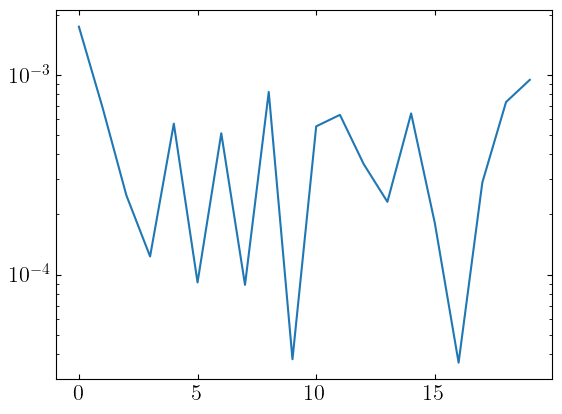

In [244]:
plt.semilogy(history["loss"], label="Total Loss")

Text(0.5, 0, 'Time step')

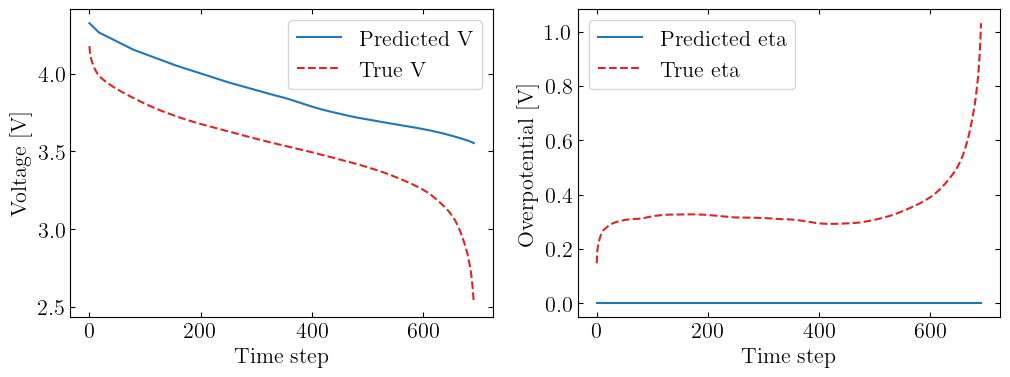

In [245]:
def evaluate(model, x_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:, :, 0]    # (B, T)
        U_eq = x_test[:, :, 2] # (B, T)

        B = x_test.shape[0]
        Fs0 = torch.zeros(B)     # (B,) initial swelling force for each trajectory

        R0 = model.r_forward(x_test)
        V_pred = ECM_box(R0, I, U_eq)
        eta_pred = I * R0

        # V_pred = model(x_test, Fs0)  # (B, T)  # Using forward for V_pred directly
    
    return V_pred.detach().numpy(), R0.detach().numpy(), eta_pred.detach().numpy()


V_pred, R0, eta_pred = evaluate(model, X_test)

idx = 24
t_max = mask_test[idx].sum()
t_len = np.linspace(0, t_max-1, t_max)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(t_len, V_pred[idx, :t_max], color=colors[0], label="Predicted V")
axs[0].plot(t_len, Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
axs[0].legend()
axs[0].set_ylabel("Voltage [V]")
axs[0].set_xlabel("Time step")
axs[1].plot(t_len, eta_pred[idx, :t_max], color=colors[0], label="Predicted eta")
axs[1].plot(t_len, - Y_test[idx, :t_max, 2], linestyle='--', color=colors[1], label="True eta")
axs[1].legend()
axs[1].set_ylabel("Overpotential [V]")
axs[1].set_xlabel("Time step")
# axs[1].plot(t_len, 30*R0[idx, :t_max], color=colors[0], label="Predicted R")